In [1]:
import torch
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from torch.utils.data import DataLoader
from transformers import XLNetTokenizer
from sklearn.metrics import confusion_matrix, classification_report
import sys
import os

# Add src to path
sys.path.append(os.path.abspath('..'))

from src.dataset import get_datasets, EVASION_MAP_9, EVASION_MAP_5, CLARITY_MAP
from src.model import SingleHeadXLNet

# Config
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
BATCH_SIZE = 16
CLARITY_NAMES = ["Clear Reply", "Ambivalent", "Clear Non-Reply"]

print(f"Using device: {DEVICE}")

Using device: cpu


In [ ]:
# 1. Load Data
tokenizer = XLNetTokenizer.from_pretrained('xlnet-base-cased')

# Wir laden die Datasets für alle 3 Modi
# Wichtig: Wir brauchen nur das Test-Set
_, test_ds_direct, _, _ = get_datasets('../data/raw/train.csv', '../data/raw/test.csv', tokenizer, mode='clarity')
_, test_ds_hier, _, _ = get_datasets('../data/raw/train.csv', '../data/raw/test.csv', tokenizer, mode='evasion_9')
_, test_ds_red, _, _ = get_datasets('../data/raw/train.csv', '../data/raw/test.csv', tokenizer, mode='evasion_5')

loaders = {
    "Direct": DataLoader(test_ds_direct, batch_size=BATCH_SIZE),
    "Hierarchical": DataLoader(test_ds_hier, batch_size=BATCH_SIZE),
    "Reduced": DataLoader(test_ds_red, batch_size=BATCH_SIZE)
}

# 2. Init Models
models = {
    "Direct": SingleHeadXLNet(num_labels=3).to(DEVICE),
    "Hierarchical": SingleHeadXLNet(num_labels=9).to(DEVICE),
    "Reduced": SingleHeadXLNet(num_labels=5).to(DEVICE)
}

# 3. Load Weights
# Stelle sicher, dass die Pfade stimmen!
models["Direct"].load_state_dict(torch.load('../models/xlnet_direct_clarity.pt', map_location=DEVICE))
models["Hierarchical"].load_state_dict(torch.load('../models/xlnet_hierarchical_k9.pt', map_location=DEVICE))
models["Reduced"].load_state_dict(torch.load('../models/xlnet_reduced_k5.pt', map_location=DEVICE))

print("Models loaded successfully.")

--- Loading Datasets (Mode: clarity) ---
Applying Democratic Voting Logic to Test Set...
Train size: 3448 | Test size: 308
--- Loading Datasets (Mode: evasion_9) ---
Applying Democratic Voting Logic to Test Set...
Train size: 3448 | Test size: 308
--- Loading Datasets (Mode: evasion_5) ---
Applying Democratic Voting Logic to Test Set...
Train size: 3448 | Test size: 308
loading xlnet-base-cased with 3 labels...
loading xlnet-base-cased with 9 labels...
loading xlnet-base-cased with 5 labels...
Models loaded successfully.


In [3]:
# Mappings Arrays (wie im Training definiert)
MAPPING_K9 = np.array([0, 1, 1, 1, 1, 2, 2, 2, 1])
MAPPING_K5 = np.array([0, 1, 1, 1, 2])

def get_predictions(model_name):
    model = models[model_name]
    loader = loaders[model_name]
    model.eval()
    
    preds_raw = []
    trues_clarity = []
    
    with torch.no_grad():
        for batch in loader:
            ids = batch['input_ids'].to(DEVICE)
            mask = batch['attention_mask'].to(DEVICE)
            
            logits = model(ids, mask)
            preds_raw.extend(torch.argmax(logits, dim=1).cpu().numpy())
            
            # Immer die echte Clarity Truth nehmen
            trues_clarity.extend(batch['clarity_truth'].numpy())
            
    preds_raw = np.array(preds_raw)
    trues_clarity = np.array(trues_clarity)
    
    # Mapping anwenden
    if model_name == "Direct":
        preds_final = preds_raw # Kein Mapping nötig
    elif model_name == "Hierarchical":
        preds_final = MAPPING_K9[preds_raw]
    elif model_name == "Reduced":
        preds_final = MAPPING_K5[preds_raw]
        
    return trues_clarity, preds_final

# Run Predictions
results = {}
for name in models.keys():
    print(f"Predicting {name}...")
    y_true, y_pred = get_predictions(name)
    results[name] = (y_true, y_pred)

Predicting Direct...
Predicting Hierarchical...
Predicting Reduced...


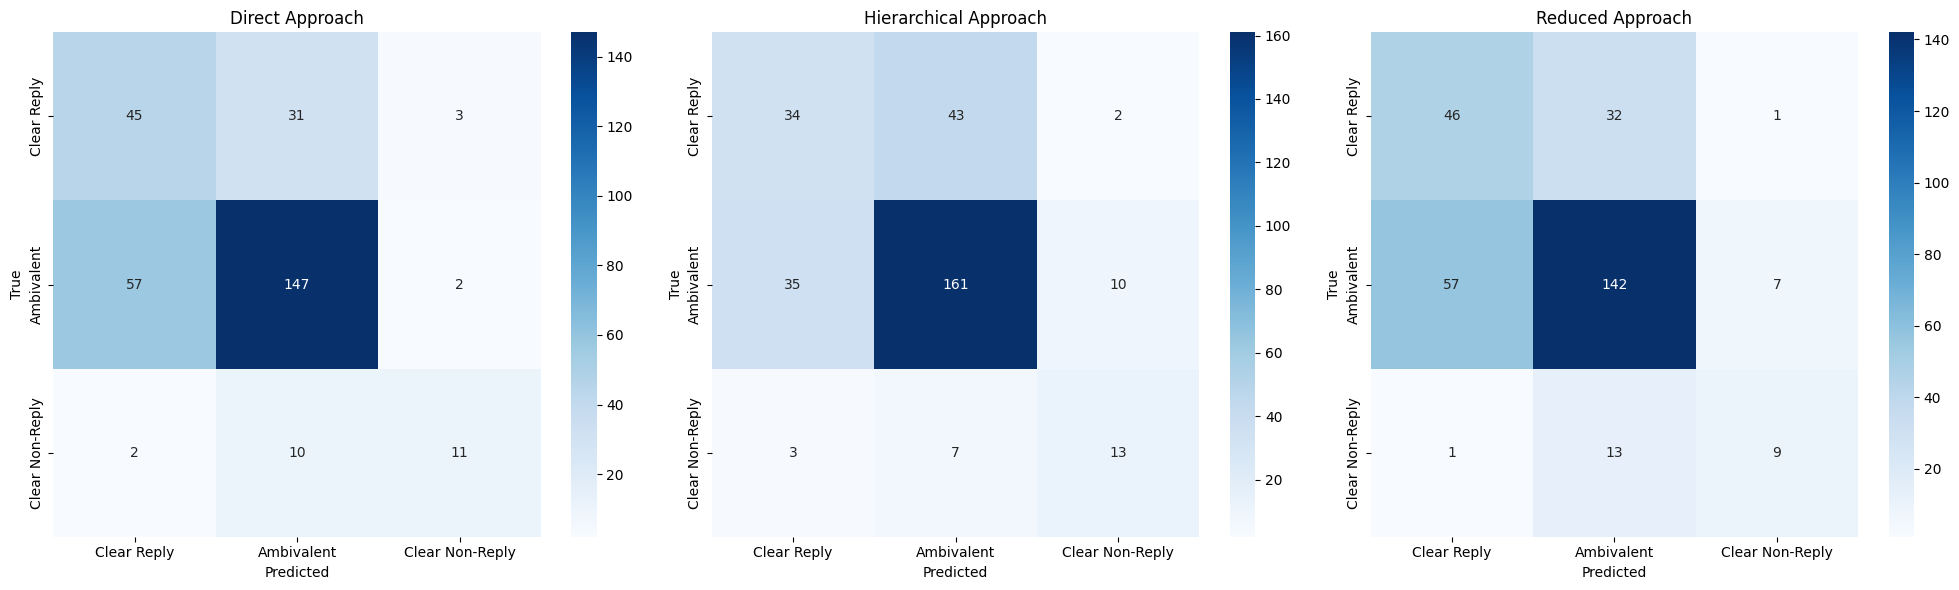

In [4]:
fig, axes = plt.subplots(1, 3, figsize=(20, 6))

for i, (name, (y_true, y_pred)) in enumerate(results.items()):
    cm = confusion_matrix(y_true, y_pred)
    
    # Normalize for better visualization (optional, remove fmt='.2f' if raw numbers wanted)
    # cm_norm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
    
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[i],
                xticklabels=CLARITY_NAMES, yticklabels=CLARITY_NAMES)
    
    axes[i].set_title(f"{name} Approach")
    axes[i].set_xlabel('Predicted')
    axes[i].set_ylabel('True')

plt.tight_layout()
plt.show()

In [5]:
# Erstelle eine schöne Tabelle für den Vergleich
final_metrics = []

for name, (y_true, y_pred) in results.items():
    report = classification_report(y_true, y_pred, target_names=CLARITY_NAMES, output_dict=True)
    final_metrics.append({
        "Model": name,
        "Macro F1": report['macro avg']['f1-score'],
        "Accuracy": report['accuracy'],
        "F1 (Ambivalent)": report['Ambivalent']['f1-score'],
        "F1 (Clear Reply)": report['Clear Reply']['f1-score'],
        "F1 (Clear Non-Reply)": report['Clear Non-Reply']['f1-score']
    })

df_results = pd.DataFrame(final_metrics)
display(df_results)

# Optional: Als CSV speichern für LaTeX Tabelle
# df_results.to_csv('final_results.csv', index=False)

,Model,Macro F1,Accuracy,F1 (Ambivalent),F1 (Clear Reply),F1 (Clear Non-Reply)
0,Direct,0.60070,0.659091,0.746193,0.491803,0.564103
1,Hierarchical,0.58806,0.675325,0.772182,0.450331,0.541667
2,Reduced,0.55846,0.639610,0.722646,0.502732,0.450000


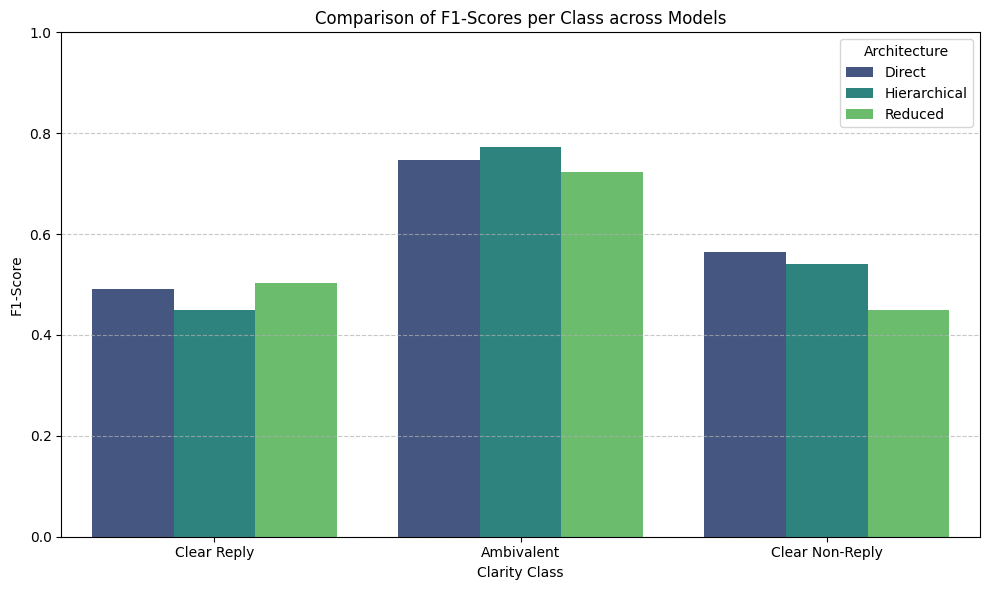

Interpretationshilfe:
- Wenn 'Hierarchical' bei 'Clear Non-Reply' höher ist als 'Direct',
  hat der Umweg über Evasion geholfen, die seltene Klasse zu finden.


In [6]:
# --- PLOT 1: Class-wise F1 Comparison ---

# Daten sammeln (aus den results, die du oben schon berechnet hast)
plot_data = []

for model_name, (y_true, y_pred) in results.items():
    report = classification_report(y_true, y_pred, target_names=CLARITY_NAMES, output_dict=True)
    
    for cls in CLARITY_NAMES:
        plot_data.append({
            "Model": model_name,
            "Class": cls,
            "F1-Score": report[cls]['f1-score']
        })

df_plot = pd.DataFrame(plot_data)

# Plotten
plt.figure(figsize=(10, 6))
sns.barplot(data=df_plot, x="Class", y="F1-Score", hue="Model", palette="viridis")
plt.title("Comparison of F1-Scores per Class across Models")
plt.ylabel("F1-Score")
plt.xlabel("Clarity Class")
plt.ylim(0, 1.0)
plt.legend(title="Architecture")
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

# Interpretation printen
print("Interpretationshilfe:")
print("- Wenn 'Hierarchical' bei 'Clear Non-Reply' höher ist als 'Direct',")
print("  hat der Umweg über Evasion geholfen, die seltene Klasse zu finden.")

--- Loading Datasets (Mode: evasion_9) ---
Applying Democratic Voting Logic to Test Set...
Train size: 3448 | Test size: 308


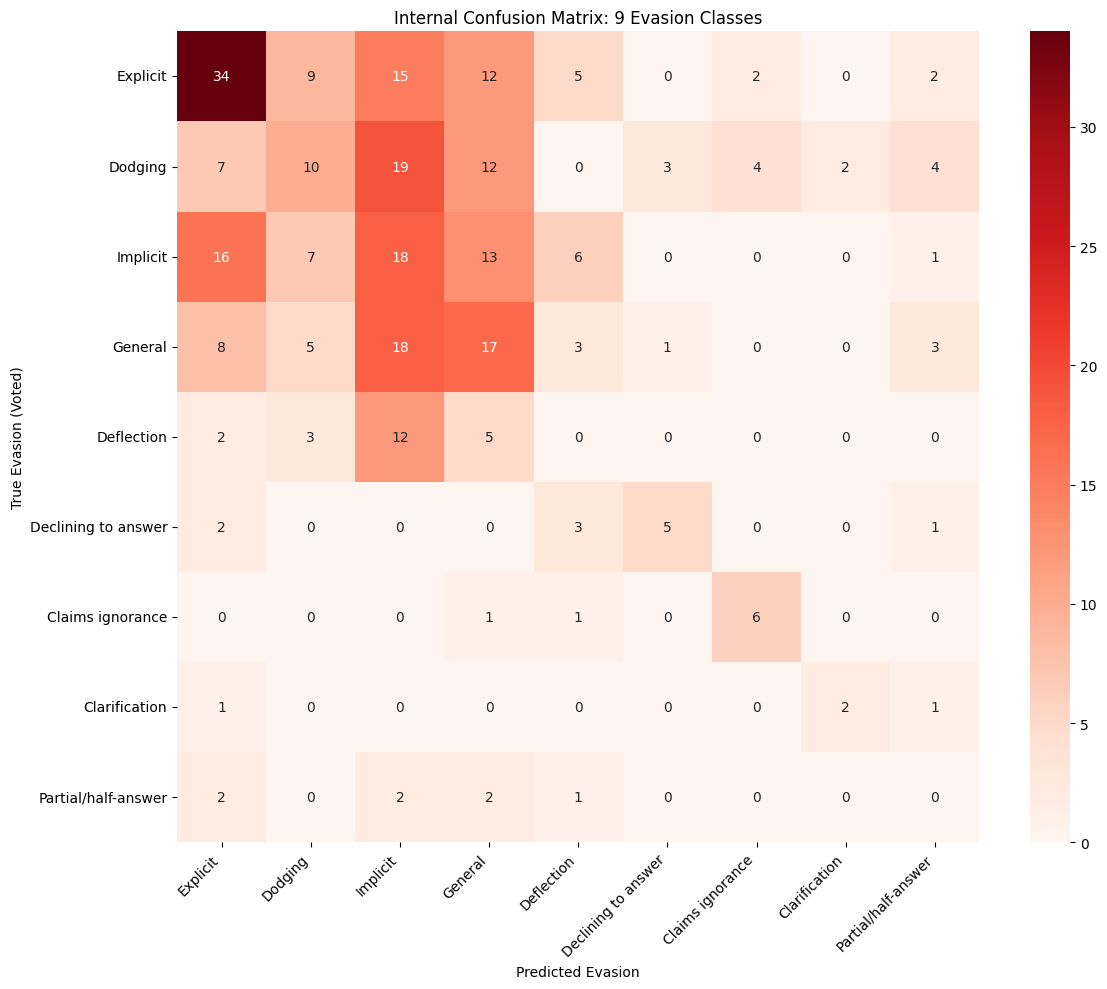

In [ ]:
# --- PLOT 2: Internal Evasion Confusion Matrix (Hierarchical k=9) ---
# Wir müssen nochmal vorhersagen, aber diesmal die RAW Evasion Labels holen

"""
Warum wichtig: Zeigt, ob das Modell z.B. "Dodging" und "Deflection" verwechselt. Das bestätigt oder 
widerlegt die These, dass manche Klassen semantisch zu ähnlich sind (was dann RQ3 mit den 5 Klassen 
motiviert)
"""

# Dataset und Loader für Evasion 9 holen
_, _, _, test_df_ev9 = get_datasets('../data/raw/train.csv', '../data/raw/test.csv', tokenizer, mode='evasion_9')
# Wichtig: Wir brauchen die Namen der 9 Labels für den Plot
evasion_labels_9 = list(EVASION_MAP_9.keys()) 
# Sortieren nach ID (0..8) damit die Matrix stimmt
evasion_labels_9_sorted = sorted(evasion_labels_9, key=lambda x: EVASION_MAP_9[x])

model_hier = models["Hierarchical"]
model_hier.eval()

preds_evasion = []
trues_evasion = []

# Wir brauchen einen Loader, der die Evasion-Labels (0-8) liefert
# Der existierende 'loaders["Hierarchical"]' tut das (batch['labels'])
with torch.no_grad():
    for batch in loaders["Hierarchical"]:
        ids = batch['input_ids'].to(DEVICE)
        mask = batch['attention_mask'].to(DEVICE)
        labels = batch['labels'].to(DEVICE) # Das sind hier die 0-8 Evasion Labels
        
        logits = model_hier(ids, mask)
        preds_evasion.extend(torch.argmax(logits, dim=1).cpu().numpy())
        trues_evasion.extend(labels.cpu().numpy())

# Plot Matrix
cm_ev = confusion_matrix(trues_evasion, preds_evasion)
plt.figure(figsize=(12, 10))
sns.heatmap(cm_ev, annot=True, fmt='d', cmap='Reds', 
            xticklabels=evasion_labels_9_sorted, 
            yticklabels=evasion_labels_9_sorted)
plt.title("Internal Confusion Matrix: 9 Evasion Classes")
plt.xlabel("Predicted Evasion")
plt.ylabel("True Evasion (Voted)")
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

In [ ]:
# --- PLOT 3: Qualitative Error Analysis ---
# Wir suchen Beispiele, wo die Modelle sich unterscheiden

# Hole die Texte zurück (aus dem DataFrame)
# Wir laden test_df nochmal roh, um den Text zu haben
test_df_raw = pd.read_csv('../data/raw/test.csv').fillna("")
test_texts = test_df_raw['clean_answer'].tolist()
test_questions = test_df_raw['clean_question'].tolist()

# Hole Vorhersagen
_, pred_direct = results["Direct"]
_, pred_hier = results["Hierarchical"]
true_clarity, _ = results["Direct"] # Truth ist bei allen gleich

print("=== ERROR ANALYSIS EXAMPLES ===\n")

# Fall 1: Hierarchical hat recht, Direct hat unrecht
# Das sind die "Gewinne" durch deine Methode
hits = 0
print("--- Case: Hierarchical Correct, Direct Incorrect ---")
for i in range(len(test_texts)):
    if hits >= 3: break # Nur 3 Beispiele
    
    if pred_hier[i] == true_clarity[i] and pred_direct[i] != true_clarity[i]:
        cls_true = CLARITY_NAMES[true_clarity[i]]
        cls_hier = CLARITY_NAMES[pred_hier[i]]
        cls_dir = CLARITY_NAMES[pred_direct[i]]
        
        print(f"\n[Example {i}]")
        print(f"Q: {test_questions[i]}")
        print(f"A: {test_texts[i][:200]}...") # Erste 200 Zeichen
        print(f"True Label: {cls_true}")
        print(f"Hierarchical Prediction: {cls_hier} (CORRECT)")
        print(f"Direct Prediction:       {cls_dir} (WRONG)")
        hits += 1

# Fall 2: Beide falsch (Die ganz schweren Fälle)
hits = 0
print("\n--- Case: Both Models Wrong (Hard Cases) ---")
for i in range(len(test_texts)):
    if hits >= 3: break
    
    if pred_hier[i] != true_clarity[i] and pred_direct[i] != true_clarity[i]:
        cls_true = CLARITY_NAMES[true_clarity[i]]
        cls_hier = CLARITY_NAMES[pred_hier[i]]
        cls_dir = CLARITY_NAMES[pred_direct[i]]
        
        print(f"\n[Example {i}]")
        print(f"A: {test_texts[i][:150]}...")
        print(f"True: {cls_true} | Hier: {cls_hier} | Dir: {cls_dir}")
        hits += 1

=== ERROR ANALYSIS EXAMPLES ===

--- Case: Hierarchical Correct, Direct Incorrect ---

[Example 3]
Q: when will we see this resolution
A: i will let condi talk about the detail of what she is going to do today if you care to hear from her but we will work with our partner to get the resolution laid down a quickly a possible and the reso...
True Label: Ambivalent
Hierarchical Prediction: Ambivalent (CORRECT)
Direct Prediction:       Clear Reply (WRONG)

[Example 8]
Q: what are you offering the arab nation to encourage them to participate
A: right well that is why condi is making the trip she is making is to explain to people in private a well a in public that one we are for comprehensive peace two that there is athe meeting the internati...
True Label: Ambivalent
Hierarchical Prediction: Ambivalent (CORRECT)
Direct Prediction:       Clear Reply (WRONG)

[Example 22]
Q: what are the odds for a guestworker provision
A: well that is got to be an integral part of a comprehensive plan when y

In [ ]:
# ==========================================
# ADDING BASELINES (LOGISTIC REGRESSION)
# ==========================================
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline

print("Training Baselines for Comparison...")

# 1. Daten laden (Raw Text für LogReg)
# Wir nutzen denselben Split wie XLNet
train_df = pd.read_csv('../data/raw/train.csv').fillna("")
test_df = pd.read_csv('../data/raw/test.csv').fillna("")

# Voting Logic für Test-Set anwenden (WICHTIG für Fairness!)
test_df['final_evasion_str'] = test_df.apply(lambda row: resolve_evasion_vote(row), axis=1) # Nutzt funktion aus dataset import

# Features
X_train = train_df['interview_answer'] # Raw Text
y_train_cl = train_df['clarity_label']
y_train_ev = train_df['evasion_label']

X_test = test_df['interview_answer']
y_test_cl = test_df['clarity_label']

# 2. Train Direct LogReg
print("  - Training LogReg Direct...")
pipe_dir = Pipeline([
    ('tfidf', TfidfVectorizer(max_features=5000, ngram_range=(1,2))),
    ('clf', LogisticRegression(class_weight='balanced', max_iter=1000))
])
pipe_dir.fit(X_train, y_train_cl)
pred_logreg_dir_str = pipe_dir.predict(X_test)
# Map Strings back to IDs for plotting consistency (0,1,2)
pred_logreg_dir = [CLARITY_MAP[s] for s in pred_logreg_dir_str]

# 3. Train Hierarchical LogReg
print("  - Training LogReg Hierarchical...")
# Filter invalid evasion labels for training
mask = y_train_ev.isin(EVASION_MAP_9.keys())
pipe_hier = Pipeline([
    ('tfidf', TfidfVectorizer(max_features=5000, ngram_range=(1,2))),
    ('clf', LogisticRegression(class_weight='balanced', max_iter=1000))
])
pipe_hier.fit(X_train[mask], y_train_ev[mask])
pred_ev_str = pipe_hier.predict(X_test)
# Map Evasion String -> Clarity ID
pred_logreg_hier = []
for ev_label in pred_ev_str:
    # Evasion String -> Parent String -> Clarity ID
    parent = TAXONOMY_PARENTS.get(ev_label, 'Ambivalent')
    pred_logreg_hier.append(CLARITY_MAP[parent])

# 4. Add to Results Dictionary
# Jetzt haben wir LogReg im selben Format wie XLNet!
results["LogReg (Direct)"] = (np.array([CLARITY_MAP[l] for l in y_test_cl]), np.array(pred_logreg_dir))
results["LogReg (Hier)"] = (np.array([CLARITY_MAP[l] for l in y_test_cl]), np.array(pred_logreg_hier))

print("Baselines added to results.")